# SAR Sea-Ice Drift NetCDF Layer Viewer
This notebook provides a guided introduction to working with the NOAA PolarWatch 
SAR daily sea-ice drift NetCDF product. It covers opening and inspecting the 
dataset structure, interpreting CF-compliant metadata and coordinate variables, 
visualizing drift vectors as quiver plots on a polar stereographic map 
(EPSG:3413), and exporting the data to compressed NumPy arrays for downstream 
analysis in pandas and other libraries.

## Python libraries
Here is the installation for the libaries needed to process the data. If any libraries fail loading in the `load libraries` cell, revist what needs to be installed in `install libraries` cell. The installation only needs to run once. The requirements.txt will have all of the necessary libraries, this step confirms `Requirement already satisfied`



### Install libraries
Change cell below to `Code` from `Raw NBConvert` to execute

### Load libraries
Note:
if you see a warning `UserWarning: pyproj unable to set database path.`, it is okay to ignore. The warning is raised setting a path on the local machine.
It has not impact on the ability to use the library. The path functions prior to calling the `pyproj` library aims to fix the issue, but it doesn't always work.

In [1]:
import os
import sys
from pathlib import Path

# Derive paths from the active env rather than hard-coding
env_prefix = Path(sys.prefix)
proj_dir = env_prefix / "Library" / "share" / "proj"
bin_dir = env_prefix / "Library" / "bin"

os.add_dll_directory(str(bin_dir))

# Set both env vars for PROJ
os.environ["PROJ_DATA"] = str(proj_dir)
os.environ["PROJ_LIB"] = str(proj_dir)   # backward compatibility

# Tell pyproj explicitly where proj.db lives
from pyproj.datadir import set_data_dir
set_data_dir(str(proj_dir))

from pyproj import Transformer

import xarray as xr
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import LineString
import sqlite3

BEARING_PRECISION = 0
SPEED_PRECISION = 1
DISPLACEMENT_PRECISION = 4
COORDINATE_PRECISION = 4
SECONDS_PER_DAY = 24 * 60 * 60
OUTLIER_COLORS = {
    '00': (0.906, 0.443, 0.282),  # rgb(231,113,72)  - No outlier, under threshold
    '01': (0.000, 1.000, 0.000),  # rgb(0,255,0)     - No outlier, above threshold
    '10': (1.000, 0.000, 0.000),  # rgb(255,0,0)     - Distance outlier, under
    '11': (1.000, 0.000, 0.000),  # rgb(255,0,0)     - Distance outlier, above
    '20': (0.000, 0.000, 1.000),  # rgb(0,0,255)     - Bearing outlier, under
    '21': (0.000, 0.000, 1.000),  # rgb(0,0,255)     - Bearing outlier, above
    '30': (1.000, 1.000, 0.000),  # rgb(255,255,0)   - Mahalanobis, under
    '31': (1.000, 1.000, 0.000),  # rgb(255,255,0)   - Mahalanobis, above
    '40': (0.502, 0.000, 0.502),  # rgb(128,0,128)   - Distance+bearing, under
    '41': (0.502, 0.000, 0.502),  # rgb(128,0,128)   - Distance+bearing, above
    '50': (1.000, 0.502, 0.000),  # rgb(255,128,0)   - Mahal+distance, under
    '51': (1.000, 0.502, 0.000),  # rgb(255,128,0)   - Mahal+distance, above
    '60': (0.302, 0.302, 0.702),  # rgb(77,77,179)   - Mahal+bearing, under
    '61': (0.302, 0.302, 0.702),  # rgb(77,77,179)   - Mahal+bearing, above
    '70': (0.000, 0.000, 0.000),  # rgb(0,0,0)       - Mahal+dist+bearing, under
    '71': (0.000, 0.000, 0.000),  # rgb(0,0,0)       - Mahal+dist+bearing, above
}

C:\ProgramData\anaconda3\envs\noaa_ml\lib\site-packages\pyproj\__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
def extract_values(layer, has_outliers, epsg):
    """
    Extract and flatten all drift vector values from a single NetCDF time layer.

    Takes an xarray Dataset time slice, builds a meshgrid of projected
    start positions (X1, Y1) from the x/y coordinate arrays, computes end
    positions (X2, Y2) from the displacement variables, derives additional
    columns (velocity components, distance, speed in km/day), and
    reprojects all positions to EPSG:4326. All 2D arrays are then flattened
    and masked to valid (finite sea_ice_speed) observations only.

    Args:
        layer (xarray.Dataset): A single time slice selected via
            `ds.isel(time=n)`. Expected variables:
                - 'layer_id' (str coordinate): Source file pair identifier.
                - 'time_bnds' (float64, shape (2,)): Start and end times
                  in seconds since 2000-01-01.
                - 'x', 'y' (float64): 1D projected coordinate arrays (m,
                  EPSG:`epsg`).
                - 'sea_ice_x_displacement' (float32, y x x): X displacement (m).
                - 'sea_ice_y_displacement' (float32, y x x): Y displacement (m).
                - 'sea_ice_speed' (float32, y x x): Drift speed (m s⁻¹);
                  used as the valid data mask (finite values only).
                - 'direction_of_sea_ice_displacement' (float32, y x x):
                  Drift bearing (degrees).
                - 'outlier_category' (int16, y x x): Outlier classification
                  code; only read when `has_outliers=True`.
        has_outliers (bool): If True, extract and zero-pad outlier_category
            values to two-digit strings (e.g. 0 -> '00', 1 -> '01', 10 ->
            '10') for compatibility with OUTLIER_COLORS and the QGIS QML
            style. If False, outlier_category is set to the scalar -9.
        epsg (int): EPSG code of the projected CRS used for the NetCDF grid
            coordinates and displacement values (e.g. 3413). Used to build
            the inverse transformer for reprojecting X1/Y1/X2/Y2 back to
            EPSG:4326.

    Returns:
        dict: Flattened 1D arrays (one entry per valid observation) with
            the following keys:

            Identifiers and timestamps:
                - 'layer_id' (str): Source file pair identifier.
                - 'date_start' (str): Start datetime ('YYYY-MM-DD HH:MM:SS').
                - 'date_end' (str): End datetime ('YYYY-MM-DD HH:MM:SS').
                - 'duration_s' (float): Observation duration in seconds
                  (scalar, not rounded).

            Geographic coordinates (EPSG:4326; rounded to
            `COORDINATE_PRECISION`):
                - 'Lon1', 'Lat1' (ndarray): Start longitude/latitude (degrees).
                - 'Lon2', 'Lat2' (ndarray): End longitude/latitude (degrees).

            Projected coordinates (EPSG:`epsg`; rounded to
            `COORDINATE_PRECISION`):
                - 'X1', 'Y1' (ndarray): Start projected coordinates (m).
                - 'X2', 'Y2' (ndarray): End projected coordinates (m).

            Displacement (EPSG:`epsg`; rounded to `DISPLACEMENT_PRECISION`):
                - 'dx', 'dy' (ndarray): X/Y displacement components (m).
                - 'u_ms', 'v_ms' (ndarray): X/Y velocity components (m s⁻¹).

            Speed and direction:
                - 'speed' (ndarray): Drift speed (m s⁻¹); rounded to
                  `SPEED_PRECISION`.
                - 'speed_kmdy' (ndarray): Drift speed (km day⁻¹); rounded to
                  `SPEED_PRECISION`.
                - 'distance' (ndarray): Geodesic displacement distance (m);
                  rounded to `SPEED_PRECISION`.
                - 'direction' (ndarray): Drift bearing (degrees); rounded to
                  `BEARING_PRECISION`.

            Outlier flag:
                - 'outlier_category' (ndarray of str or int): Two-digit
                  zero-padded outlier codes if `has_outliers=True`, otherwise
                  the scalar -9.

    Notes:
        - End positions are computed as X2 = X1 + dx, Y2 = Y1 + dy in
          EPSG:`epsg` projected space.
        - Rounding uses module-level constants: COORDINATE_PRECISION,
          DISPLACEMENT_PRECISION, SPEED_PRECISION, and BEARING_PRECISION.
        - Speed conversion to km/day uses the module-level constant
          SECONDS_PER_DAY.
        - `distance` is derived from geodesic speed × duration rather than
          from `sqrt(dx² + dy²)`; it is therefore consistent with
          `sea_ice_speed` rather than with `u_ms`/`v_ms`.
    """  
    
    # layer id
    layer_id = str(layer['layer_id'].values)

    # time
    epoch = pd.Timestamp('2000-01-01')
    date_start = epoch + pd.to_timedelta(
        float(layer['time_bnds'].values[0]), unit='s'
    )
    date_end = epoch + pd.to_timedelta(
        float(layer['time_bnds'].values[1]), unit='s'
    )
    duration_s = (date_end - date_start).total_seconds()

    # meshgrid: X1, Y1 for every grid cell
    y_coords = layer['y'].values
    x_coords = layer['x'].values
    X1, Y1 = np.meshgrid(x_coords, y_coords)

    # supplied data values
    dx = np.round(layer['sea_ice_x_displacement'].values.astype(float), DISPLACEMENT_PRECISION)
    dy = np.round(layer['sea_ice_y_displacement'].values.astype(float), DISPLACEMENT_PRECISION)
    X2 = X1 + dx
    Y2 = Y1 + dy
    speed = np.round(layer['sea_ice_speed'].values.astype(float), SPEED_PRECISION)
    direction = np.round(layer['direction_of_sea_ice_displacement'].values.astype(float), BEARING_PRECISION)

    # derived data values
    u_ms = dx / duration_s
    v_ms = dy / duration_s
    distance = speed * duration_s
    speed_kmdy = (distance / 1000) / (duration_s / SECONDS_PER_DAY)

    # reproject to EPSG:4326
    transformer = Transformer.from_crs(
        f'EPSG:{epsg}', 'EPSG:4326', always_xy=True
    )
    lon1, lat1 = transformer.transform(X1, Y1)
    lon2, lat2 = transformer.transform(X2, Y2)

    # flatten and mask to valid cells only
    valid_mask = np.isfinite(speed)

    return {
        'layer_id':         layer_id,
        'date_start':       date_start.strftime('%Y-%m-%d %H:%M:%S'),
        'date_end':         date_end.strftime('%Y-%m-%d %H:%M:%S'),
        'duration_s':       duration_s,
        'Lon1':             np.round(lon1[valid_mask], COORDINATE_PRECISION),
        'Lat1':             np.round(lat1[valid_mask], COORDINATE_PRECISION),
        'Lon2':             np.round(lon2[valid_mask], COORDINATE_PRECISION),
        'Lat2':             np.round(lat2[valid_mask], COORDINATE_PRECISION),
        'X1':               np.round(X1[valid_mask],  COORDINATE_PRECISION),
        'Y1':               np.round(Y1[valid_mask],  COORDINATE_PRECISION),
        'X2':               np.round(X2[valid_mask],  COORDINATE_PRECISION),
        'Y2':               np.round(Y2[valid_mask],  COORDINATE_PRECISION),
        'dx':               np.round(dx[valid_mask],  DISPLACEMENT_PRECISION),
        'dy':               np.round(dy[valid_mask],  DISPLACEMENT_PRECISION),
        'u_ms':             np.round(u_ms[valid_mask], DISPLACEMENT_PRECISION),
        'v_ms':             np.round(v_ms[valid_mask], DISPLACEMENT_PRECISION),
        'speed':            np.round(speed[valid_mask],     SPEED_PRECISION),
        'speed_kmdy':       np.round(speed_kmdy[valid_mask], SPEED_PRECISION),
        'distance':         np.round(distance[valid_mask],  SPEED_PRECISION),
        'direction':        np.round(direction[valid_mask], BEARING_PRECISION),
        'outlier_category': (
            np.array([f'{int(v):02d}' for v in layer['outlier_category'].values[valid_mask]])
            if has_outliers else -9
        )
    }

In [3]:
def layer_to_gpkg(layer_values, has_outliers, epsg):
    """
    Export a single sea-ice drift layer to a GeoPackage file with an
    embedded QGIS style.

    Builds a LineString geometry for each valid observation from projected
    start (X1, Y1) to end (X2, Y2) coordinates in EPSG:`epsg`, constructs
    a GeoDataFrame with all drift attributes, writes it to a GeoPackage
    file in the 'layer_to_gpkg/' directory, and embeds the appropriate
    QGIS QML style via `_embed_qml_style`.

    The output filename is derived from `layer_values['layer_id']`.

    Args:
        layer_values (dict): Output of `extract_values()`. Required keys:
            - 'layer_id' (str): Used as the output filename stem.
            - 'Lon1', 'Lat1' (ndarray): Start longitude/latitude
              (EPSG:4326, degrees).
            - 'Lon2', 'Lat2' (ndarray): End longitude/latitude
              (EPSG:4326, degrees).
            - 'X1', 'Y1' (ndarray): Start projected coordinates
              (m, EPSG:`epsg`).
            - 'X2', 'Y2' (ndarray): End projected coordinates
              (m, EPSG:`epsg`).
            - 'date_start', 'date_end' (str): Observation start/end
              datetimes.
            - 'duration_s' (float): Observation duration in seconds.
            - 'dx', 'dy' (ndarray): X/Y displacement components (m).
            - 'u_ms', 'v_ms' (ndarray): X/Y velocity components (m s⁻¹).
            - 'speed' (ndarray): Drift speed (m s⁻¹).
            - 'speed_kmdy' (ndarray): Drift speed (km day⁻¹).
            - 'direction' (ndarray): Drift bearing (degrees).
            - 'distance' (ndarray): Geodesic displacement distance (m).
            - 'outlier_category' (ndarray of str or int): Two-digit
              zero-padded outlier codes if `has_outliers=True`,
              otherwise -9.
        has_outliers (bool): Controls which QGIS QML style is embedded:
            - True:  'meta/outlier_style.qml' — categorical colors per
              outlier code.
            - False: 'meta/graduated_quivers.qml' — graduated color ramp
              by speed or magnitude.
        epsg (int): EPSG code of the projected CRS used for X1/Y1/X2/Y2
            coordinates and set as the GeoPackage layer CRS
            (e.g. 3413, 6931).

    Returns:
        None

    Output:
        GeoPackage file written to 'layer_to_gpkg/<layer_id>.gpkg' with a
        single layer named 'drift_lines' in EPSG:`epsg`. The embedded QML
        style allows the file to render correctly when opened directly in
        QGIS.

    Raises:
        ValueError: If the selected QML style file does not exist on disk.
    """
    
    # decide which quiver style to use based on if the layer has outliers
    if has_outliers:
        quiver_style = r'meta/outlier_style.qml'
    else:
        quiver_style = r'meta/graduated_quivers.qml'
    if not os.path.exists(quiver_style):
        raise ValueError(
            f'{quiver_style} file not located. Please be sure to download '
            f'contents of `meta` folder in GitHub.'
        )

    # build geometries from flat scalar arrays
    locations = zip(
        layer_values['X1'], layer_values['Y1'],
        layer_values['X2'], layer_values['Y2']
    )
    geometries = [
        LineString([(x1, y1), (x2, y2)])
        for x1, y1, x2, y2 in locations
    ]

    layer_id = layer_values['layer_id']

    gdf = gpd.GeoDataFrame(
        {
            'layer_id':                          layer_id,
            'longitude_1':                       layer_values['Lon1'],
            'latitude_1':                        layer_values['Lat1'],
            'longitude_2':                       layer_values['Lon2'],
            'latitude_2':                        layer_values['Lat2'],
            'X1':                                layer_values['X1'],
            'Y1':                                layer_values['Y1'],
            'X2':                                layer_values['X2'],
            'Y2':                                layer_values['Y2'],
            'date_start':                        layer_values['date_start'],
            'date_end':                          layer_values['date_end'],
            'duration_s':                        layer_values['duration_s'],
            'sea_ice_x_displacement':            layer_values['dx'],
            'sea_ice_y_displacement':            layer_values['dy'],
            'u_ms':                              layer_values['u_ms'],
            'v_ms':                              layer_values['v_ms'],
            'sea_ice_speed':                     layer_values['speed'],
            'sea_ice_speed_kmdy':                layer_values['speed_kmdy'],
            'direction_of_sea_ice_displacement': layer_values['direction'],
            'distance':                          layer_values['distance'],
            'outlier_category':                  layer_values['outlier_category'],
            'geometry_type':                     'line'
        },
        geometry=geometries,
        crs=f'EPSG:{epsg}'
    )

    # save as GeoPackage
    os.makedirs('layer_to_gpkg', exist_ok=True)
    output_file_path = os.path.join('layer_to_gpkg', f'{layer_id}.gpkg')
    # delete previous file so it does not get appended
    if os.path.exists(output_file_path):
        os.remove(output_file_path)
    gdf.to_file(output_file_path, layer='drift_vectors', driver='GPKG')

    # embed .qml outlier layer style
    _embed_qml_style(output_file_path, 'drift_vectors', quiver_style)

In [4]:
def create_png(layer_values, has_outliers, epsg):
    """
    Render a quiver plot of sea-ice drift vectors and display it inline.

    Vectors are plotted using start positions (X1, Y1) and displacement
    components (dx, dy) from `layer_values`. The Cartopy projection is
    selected dynamically based on `epsg`:
        - 3413 or 3411 : WGS84 North Polar Stereographic
                         (central longitude −45°, true-scale latitude 70°N).
                         Note: both EPSG codes use the same Cartopy
                         projection parameters since Cartopy does not
                         distinguish ellipsoids for polar stereographic
                         projections.
        - 6931         : Lambert Azimuthal Equal-Area, centred at 90°N.
        - Other        : Falls back to WGS84 North Polar Stereographic
                         with a warning printed to stdout.

    The map extent is derived from the bounding box of all start and end
    positions with a fixed 300 km pad on each side.

    Arrow coloring has two modes controlled by `has_outliers`:
        - True: per-arrow colors matching the QGIS outlier_style.qml
          category definitions (OUTLIER_COLORS), with a legend showing
          only the outlier codes present in this layer. The legend
          includes a note explaining that '(under)' means below the
          neighbor threshold and '(above)' means at or above it.
        - False: viridis colormap scaled to displacement magnitude (m),
          with a colorbar labeled 'Displacement magnitude (m)'.

    Args:
        layer_values (dict): Output of `extract_values()`. Required keys:
            - 'X1', 'Y1' (ndarray): Projected start positions (m,
              EPSG:`epsg`).
            - 'X2', 'Y2' (ndarray): Projected end positions (m,
              EPSG:`epsg`).
            - 'dx', 'dy' (ndarray): X/Y displacement components (m).
            - 'speed' (ndarray): Sea-ice speed (m s⁻¹); used for
              observation count in the plot title.
            - 'outlier_category' (ndarray of str): Two-digit zero-padded
              outlier codes per observation (e.g. '00', '01', '10').
              Only required when `has_outliers=True`.
        has_outliers (bool): If True, color arrows by outlier category
            using OUTLIER_COLORS and render a categorical legend.
            If False, color by displacement magnitude using viridis
            and render a colorbar.
        epsg (int): EPSG code of the projected CRS used for X1/Y1/X2/Y2
            coordinates. Controls the Cartopy projection used for
            rendering. Supported values: 3413, 3411, 6931.

    Returns:
        None

    Notes:
        - EPSG:3411 and EPSG:3413 both render using the same Cartopy
          North Polar Stereographic parameters (central longitude −45°,
          true-scale latitude 70°, WGS84 globe) since Cartopy does not
          expose ellipsoid selection for polar stereographic projections.
        - For unsupported EPSG values, the function falls back to North
          Polar Stereographic and prints a warning.
    """

    # select Cartopy projection based on EPSG
    if epsg in (3413, 3411):
        cartopy_crs = ccrs.NorthPolarStereo(
            central_longitude=-45,
            true_scale_latitude=70,
            globe=ccrs.Globe(datum='WGS84', ellipse='WGS84')
        )
    elif epsg == 6931:
        cartopy_crs = ccrs.LambertAzimuthalEqualArea(
            central_longitude=0,
            central_latitude=90,
            globe=ccrs.Globe(datum='WGS84', ellipse='WGS84')
        )
    else:
        print(
            f'Warning: unsupported EPSG:{epsg} for Cartopy projection. '
            f'Falling back to North Polar Stereographic (EPSG:3413).'
        )
        cartopy_crs = ccrs.NorthPolarStereo(
            central_longitude=-45,
            true_scale_latitude=70,
            globe=ccrs.Globe(datum='WGS84', ellipse='WGS84')
        )

    fig = plt.figure(figsize=(16, 16))
    ax = plt.axes(projection=cartopy_crs)

    X1_valid = layer_values['X1']
    Y1_valid = layer_values['Y1']
    X2_valid = layer_values['X2']
    Y2_valid = layer_values['Y2']
    dx       = layer_values['dx']
    dy       = layer_values['dy']

    # extent from full vector bounding box
    pad = 300_000  # 300 km
    xmin = np.round(min(X1_valid.min(), X2_valid.min()) - pad, 3)
    xmax = np.round(max(X1_valid.max(), X2_valid.max()) + pad, 3)
    ymin = np.round(min(Y1_valid.min(), Y2_valid.min()) - pad, 3)
    ymax = np.round(max(Y1_valid.max(), Y2_valid.max()) + pad, 3)

    ax.set_extent([xmin, xmax, ymin, ymax], crs=cartopy_crs)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.coastlines(resolution="10m", linewidth=1.0, zorder=1)

    if has_outliers:
        outlier_valid = layer_values['outlier_category']
        code_strs = [f'{int(c):02d}' for c in np.asarray(outlier_valid)]
        quiver_colors = [OUTLIER_COLORS.get(c, (0.5, 0.5, 0.5)) for c in code_strs]

        q = ax.quiver(
            X1_valid, Y1_valid, dx, dy,
            transform=cartopy_crs, angles="xy", scale_units="xy", scale=1,
            width=0.002, pivot="tail", color=quiver_colors, zorder=2
        )

        legend_labels = {
            '00': 'No outlier (under)',      '01': 'No outlier (above)',
            '10': 'Distance (under)',        '11': 'Distance (above)',
            '20': 'Bearing (under)',         '21': 'Bearing (above)',
            '30': 'Mahalanobis (under)',     '31': 'Mahalanobis (above)',
            '40': 'Dist+bearing (under)',    '41': 'Dist+bearing (above)',
            '50': 'Mahal+dist (under)',      '51': 'Mahal+dist (above)',
            '60': 'Mahal+bearing (under)',   '61': 'Mahal+bearing (above)',
            '70': 'Mahal+dist+bear (under)', '71': 'Mahal+dist+bear (above)',
        }
        unique_codes = sorted(set(code_strs))
        handles = [
            Patch(color=OUTLIER_COLORS[c], label=legend_labels.get(c, c))
            for c in unique_codes if c in OUTLIER_COLORS
        ]
        handles.append(Patch(color='none', label=''))
        handles.append(Patch(color='none', label='(under) = below neighbor\nthreshold'))
        handles.append(Patch(color='none', label='(above) = at or above neighbor\nthreshold'))
        ax.legend(handles=handles, loc='lower left', fontsize=8, framealpha=0.8)

    else:
        mag_valid = np.hypot(dx, dy)
        norm = mcolors.Normalize(vmin=mag_valid.min(), vmax=mag_valid.max())
        q = ax.quiver(
            X1_valid, Y1_valid, dx, dy, mag_valid,
            transform=cartopy_crs, angles="xy", scale_units="xy", scale=1,
            width=0.002, pivot="tail", cmap='viridis', norm=norm, zorder=2
        )
        cbar = fig.colorbar(q, ax=ax, orientation="vertical", shrink=0.65, pad=0.02)
        cbar.set_label("Displacement magnitude (m)")

    ax.set_title(
        f"Sea-ice Vector Velocities\n"
        f"x {xmin} to {xmax}; y {ymin} to {ymax}\n"
        f"Total observations: {len(layer_values['speed'])}\n"
        f"EPSG:{epsg}"
    )

    plt.show()

In [5]:
def _embed_qml_style(gpkg_path, layer_name, qml_path):
    """
    Embed a QML style into a GeoPackage's layer_styles table.

    Reads a QML file and writes its contents into the QGIS-standard
    layer_styles table inside the GeoPackage. QGIS will automatically
    apply the style when the layer is loaded, requiring no QML file
    on the end user's machine.

    Args:
        gpkg_path (str): Full path to the target GeoPackage file.
        layer_name (str): Name of the layer to apply the style to.
                          Must match the layer name in the GeoPackage exactly.
        qml_path (str): Full path to the QML style file to embed.

    Returns:
        None

    Notes:
        - The layer_styles table is created if it does not already exist,
          following the QGIS standard schema.
        - `f_geometry_column` is hardcoded to 'geom' because GeoPandas
          silently renames the geometry column from 'geometry' to 'geom'
          when writing to GeoPackage format.
        - `useAsDefault` is set to 1 so QGIS applies the style automatically
          on load without user intervention.
        - The layer_styles table is registered in gpkg_contents as an
          attributes layer for full GeoPackage spec compliance.
    """
    with open(qml_path, 'r') as f:
        qml_content = f.read()

    conn = sqlite3.connect(gpkg_path)
    cursor = conn.cursor()

    # Create layer_styles table if it doesn't exist (QGIS standard schema)
    cursor.execute("""
                   CREATE TABLE IF NOT EXISTS layer_styles (
                       id INTEGER PRIMARY KEY AUTOINCREMENT,
                       f_table_catalog TEXT,
                       f_table_schema TEXT,
                       f_table_name TEXT,
                       f_geometry_column TEXT,
                       styleName TEXT,
                       styleQML TEXT,
                       styleSLD TEXT,
                       useAsDefault INTEGER,
                       description TEXT,
                       owner TEXT,
                       ui TEXT,
                       update_time DATETIME DEFAULT CURRENT_TIMESTAMP
                )
                """
    )


    cursor.execute("""
                   INSERT INTO layer_styles 
                   (f_table_catalog, f_table_schema, f_table_name, 
                    f_geometry_column, styleName, styleQML, styleSLD,
                    useAsDefault, description, owner)
                   VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                   """,
                   (
                       '',           # f_table_catalog
                       '',           # f_table_schema
                       layer_name,   # f_table_name  
                       'geom',       # f_geometry_column
                       'outliers',   # styleName
                       qml_content,  # styleQML
                       '',           # styleSLD (leave blank)
                       1,            # useAsDefault
                       '',
                       ''
                    )
    )
    
    cursor.execute("""
                   INSERT OR IGNORE INTO gpkg_contents 
                   (table_name, data_type, identifier, description,
                    last_change)
                   VALUES 
                   ('layer_styles', 'attributes', 'layer_styles',
                    'QGIS layer styles', datetime('now'))
                   """
    )

    conn.commit()    
    conn.close()

## Open NetCDF file and view summary

In [6]:
# nc_path = r"SIVelocity_SAR/3413/Processing Level - 02 (PL02)/2024/nc/SIVelocity_SAR_20241230_20241231_scenes_12km_NH_3413_PL02_v01.nc"
nc_path = r"SIVelocity_SAR/3413/Processing Level - 01 (PL01)/2024/nc/SIVelocity_SAR_20241014_20241015_scenes_12km_NH_3413_PL01_v01.nc"
if not os.path.exists(nc_path):
    raise ValueError(f'Cannot locate file {nc_path}')
ds = xr.open_dataset(nc_path, decode_times=False, mask_and_scale=False)
ds

<xarray.Dataset> Size: 147MB
Dimensions:                            (time: 123, y: 240, x: 207, nv: 2)
Coordinates:
  * time                               (time) float64 984B 7.822e+08 ... 7.82...
    layer_id                           (time) <U43 21kB ...
  * nv                                 (nv) int64 16B 0 1
  * x                                  (x) float64 2kB -1.706e+06 ... 8.688e+05
  * y                                  (y) float64 2kB 1.569e+06 ... -1.419e+06
Data variables:
    sea_ice_speed                      (time, y, x) float32 24MB ...
    sea_ice_x_displacement             (time, y, x) float32 24MB ...
    sea_ice_y_displacement             (time, y, x) float32 24MB ...
    direction_of_sea_ice_displacement  (time, y, x) float32 24MB ...
    outlier_category                   (time, y, x) int16 12MB ...
    bearing_error                      (time, y, x) int16 12MB ...
    speed_error                        (time, y, x) int16 12MB ...
    measurement_error                  (time, y, x) int16 12MB ...
    spatial_ref                        int32 4B ...
    time_bnds                          (time, nv) float64 2kB ...
Attributes: (12/38)
    Conventions:               CF-1.8, ACDD-1.3
    title:                     SAR drift data converted from raw text form to...
    summary:                   NetCDF version of the SAR Daily Drift dataset....
    acknowledgement:           Produced by NOAA using IABP data.
    creator_name:              Brendon Gory
    creator_email:             brendon.gory@noaa.gov
    ...                        ...
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    date_created:              2026-05-21T20:24:27Z
    time_coverage_start:       2024-10-14T01:02:01Z
    time_coverage_end:         2024-10-15T23:04:21Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D

## Get layer of interest
If you know the scene_id shown in the daily GeoPackage for each vector or by the layer id in the NetCDF, you can get the layer index. Otherwise, you can browse the layers of the NetCDF

In [7]:
# show all layers
# print('Index\tLayer ID')
# for idx, layer in enumerate(ds["layer_id"].values):
#     print(f"{idx}\t{layer}")
    
    
    
# get index based on scene_id
target_layer = 'drift_vectors_RCM1_05_18_19_RSAT2_04_28_26' #PL-01
# target_layer = 'drift_vectors_RCM1_07_42_34_RCM3_08_22_27'#PL-02
for idx, layer in enumerate(ds['layer_id'].values):
    if layer == target_layer:
        print(idx)
        break

4


## Choose which layer to export based on layer index
Set `has_outliers` to True or False. When the PNG is created, the outlier values will be color-coded. False can always be set. Only level 02 output will have outliers. If no vectors appear in the plot, `has_outliers` might be set to true and the layer has no outlier categories.

In [8]:
epsg=3413

# PL - 01
selected_layer_index = 4
has_outliers = False

# PL - 02
# selected_layer_index = 9
# has_outliers = True



# get layer values
layer = ds.isel(time=selected_layer_index)
layer_values = extract_values(layer, has_outliers, epsg)

## Get a glimpse of the high-level statistics of the variables, their data types and sample values

In [9]:
# variable metadata
metadata = []
display_spatial_ref = False
for var in ds.data_vars:
    attrs = ds[var].attrs
    if 'spatial_ref' in var:
        # ignore spatial ref for each variable if it exists
        display_spatial_ref = True
        continue
    metadata.append(
        {
            'Variable': var,
            'Dims': ds[var].dims,
            'Dtype': ds[var].dtype,
            'Units': attrs.get('units', ''),
            'Standard Name': attrs.get('standard_name', ''),
            'Long Name': attrs.get('long_name', ''),
            'Grid Mapping': attrs.get('grid_mapping', '')
        }
    )

display(pd.DataFrame(metadata)) # display in nice data frame

,Variable,Dims,Dtype,Units,Standard Name,Long Name,Grid Mapping
0,sea_ice_speed,"(time, y, x)",float32,m s-1,sea_ice_speed,Sea ice speed,spatial_ref
1,sea_ice_x_displacement,"(time, y, x)",float32,m s-1,movement_in_x_direction,u-velocity component,spatial_ref
2,sea_ice_y_displacement,"(time, y, x)",float32,m s -1,movement_in_y_direction,v-velocity component,spatial_ref
3,direction_of_sea_ice_displacement,"(time, y, x)",float32,degrees,direction_of_sea_ice_displacement,Direction of the vector change in geospatial p...,spatial_ref
4,outlier_category,"(time, y, x)",int16,1,status_flag,Outlier category code,spatial_ref
5,bearing_error,"(time, y, x)",int16,1,status_flag,Possible bearing error flag,spatial_ref
6,speed_error,"(time, y, x)",int16,1,status_flag,Possible speed error flag,spatial_ref
7,measurement_error,"(time, y, x)",int16,1,status_flag,Possible measurement error flag,spatial_ref
8,time_bnds,"(time, nv)",float64,,,,


In [10]:
layer_id  = str(ds['layer_id'].isel(time=selected_layer_index).values)
layer_time = float(ds['time'].isel(time=selected_layer_index).values)

skip_vars = {'spatial_ref', 'time_bnds'}

stats = []
for var in ds.data_vars:
    if var in skip_vars:
        continue

    da = ds[var].isel(time=selected_layer_index)
    
    fill_value = da.attrs.get('_FillValue', None)
    arr = da.values.astype(float)   # cast int16 vars so np.nan comparisons work
    if fill_value is not None:
        arr[arr == float(fill_value)] = np.nan
    valid = np.isfinite(arr)
    invalid = ~valid

    if valid.any():
        min_val = np.round(np.nanmin(arr), 3)
        max_val = np.round(np.nanmax(arr), 3)
        mean_val = np.round(np.nanmean(arr), 3)
        median_val = np.round(np.nanmedian(arr), 3)
        std_val = np.round(np.nanstd(arr), 3)
        samples = arr[valid][:5]
        print(samples)
    else:
        min_val = max_val = mean_val = median_val = std_val = np.nan
        samples = []

    stats.append({
        'Layer ID':           layer_id,
        'Time':               layer_time,
        'Variable':           var,
        'Shape':              arr.shape,
        'Valid Count':        valid.sum(),
        'No Data':            invalid.sum(),
        'Valid Fraction':     f'{np.round(valid.mean() * 100, 2)} %',
        'Min':                min_val,
        'Max':                max_val,
        'Mean':               mean_val,
        'Median':             median_val,
        'Standard Deviation': std_val,
        'Sample Values':      samples
    })

pd.DataFrame(stats)

[0.1 0.1 0.1 0.1 0.1]
[5666.07568359 5650.64111328 5910.28271484 6087.10693359 5658.17333984]
[2946.78198242 2902.71850586 3072.23779297 3790.8762207  3302.76464844]
[-72. -72. -72. -77. -74.]
[0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0.]


,Layer ID,Time,Variable,Shape,Valid Count,No Data,Valid Fraction,Min,Max,Mean,Median,Standard Deviation,Sample Values
0,drift_vectors_RCM1_05_18_19_RSAT2_04_28_26,782198299.0,sea_ice_speed,"(240, 207)",273,49407,0.55 %,0.000,0.300,0.092,0.100,0.053,"[0.10000000149011612, 0.10000000149011612, 0.1..."
1,drift_vectors_RCM1_05_18_19_RSAT2_04_28_26,782198299.0,sea_ice_x_displacement,"(240, 207)",273,49407,0.55 %,-25190.799,20840.914,508.303,223.154,4991.439,"[5666.07568359375, 5650.64111328125, 5910.2827..."
2,drift_vectors_RCM1_05_18_19_RSAT2_04_28_26,782198299.0,sea_ice_y_displacement,"(240, 207)",273,49407,0.55 %,-12978.075,21489.588,4164.515,4068.346,3210.483,"[2946.781982421875, 2902.718505859375, 3072.23..."
3,drift_vectors_RCM1_05_18_19_RSAT2_04_28_26,782198299.0,direction_of_sea_ice_displacement,"(240, 207)",273,49407,0.55 %,-178.000,179.000,-103.941,-110.000,73.752,"[-72.0, -72.0, -72.0, -77.0, -74.0]"
4,drift_vectors_RCM1_05_18_19_RSAT2_04_28_26,782198299.0,outlier_category,"(240, 207)",0,49680,0.0 %,NaN,NaN,NaN,NaN,NaN,[]
5,drift_vectors_RCM1_05_18_19_RSAT2_04_28_26,782198299.0,bearing_error,"(240, 207)",273,49407,0.55 %,0.000,0.000,0.000,0.000,0.000,"[0.0, 0.0, 0.0, 0.0, 0.0]"
6,drift_vectors_RCM1_05_18_19_RSAT2_04_28_26,782198299.0,speed_error,"(240, 207)",273,49407,0.55 %,0.000,0.000,0.000,0.000,0.000,"[0.0, 0.0, 0.0, 0.0, 0.0]"
7,drift_vectors_RCM1_05_18_19_RSAT2_04_28_26,782198299.0,measurement_error,"(240, 207)",273,49407,0.55 %,0.000,1.000,0.172,0.000,0.378,"[0.0, 0.0, 0.0, 0.0, 0.0]"


## Close dataset
If the dataset is not closed, there will be access issues to the NetCDF file in this notebook or other applications. This cell can be separately run at any time if you encounter access issues on the NetCDF file.

In [11]:
ds.close()

## Export layer to GeoPackage

In [12]:
layer_to_gpkg(layer_values, has_outliers, epsg)

## Export layer to plot
The image can be saved locally by right clicking on the plot and choosing "Save Image As..." (depending on browser running the notebook).

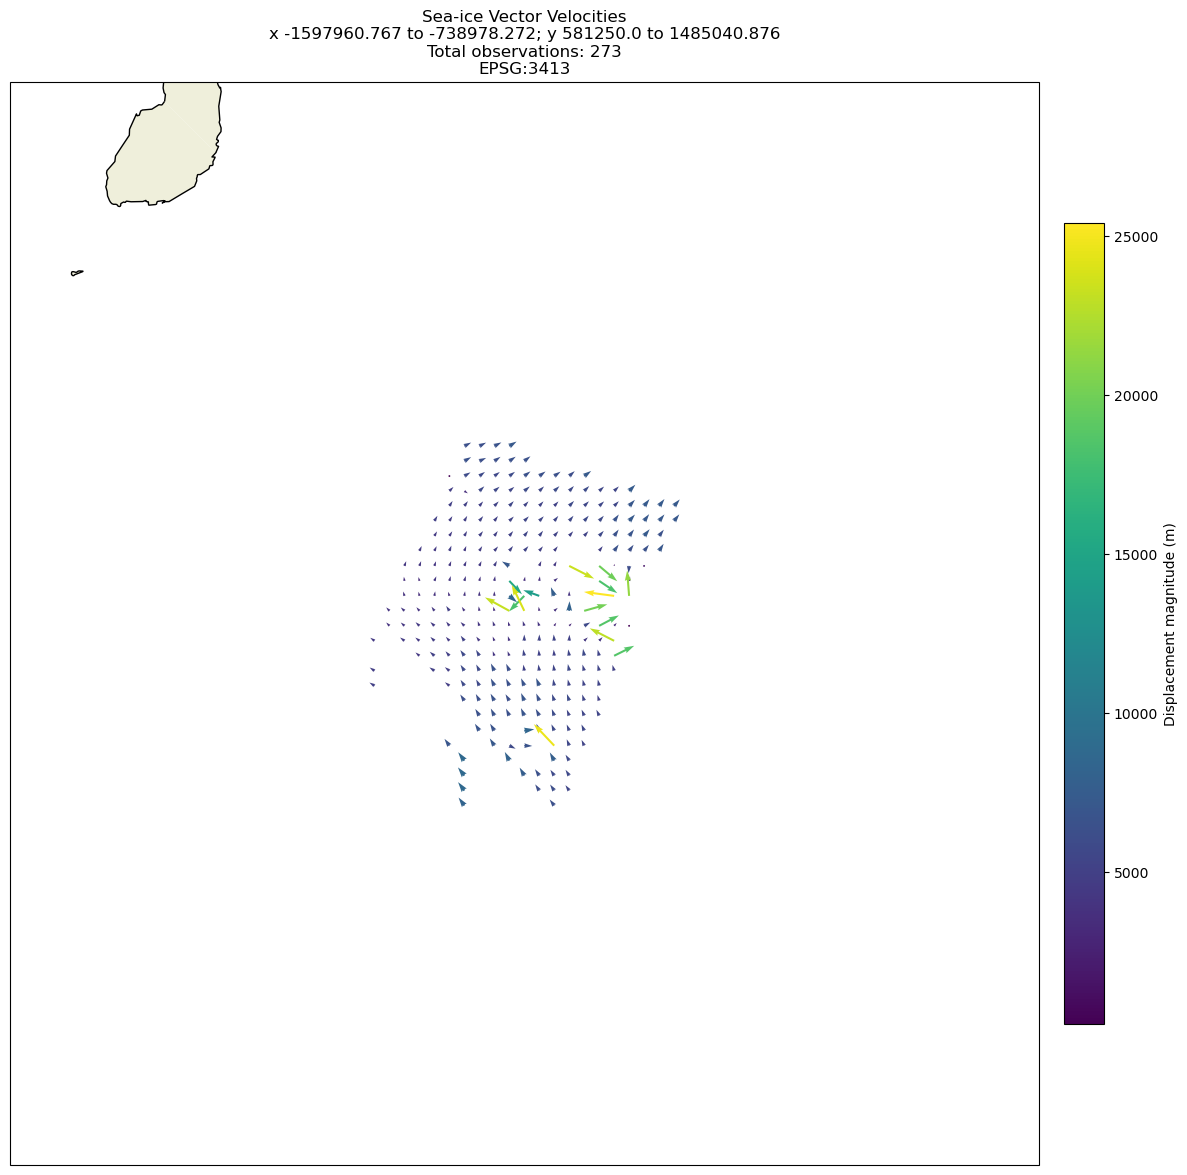

In [13]:
create_png(layer_values, has_outliers, epsg)